# Static XAS — 5 mmol glycine (run 58794)

Single-run static XAS notebook for run 58794.

This notebook follows the same binning logic as the existing static-XAS notebooks, but adds a tunable Gotthard pixel-to-photon-energy conversion using [gotthard_energy_pixel_map.py](../scripts/gotthard_energy_pixel_map.py).

Final plots are provided in three separate cells:
1. XAS vs nominal photon energy.
2. XAS vs shot-resolved photon-energy proxy in Gotthard pixels.
3. XAS vs converted photon energy from the shot-resolved pixel proxy.

In [40]:
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / 'analysis' / 'scripts').exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError('Could not locate repository root.')

sys.path.insert(0, str(repo_root / 'analysis' / 'scripts'))

import config as path_config
from gotthard_energy_pixel_map import CalibrationPoint, SpectrometerConfig, pixel_to_energy

## Config

Tune the GMD binning and the Gotthard pixel-map calibration here. The converted-energy axis in the final plot depends on `PIXEL_MAP_CONFIG`, `PIXEL_MAP_CALIBRATION`, and `INVERSE_MAP_RANGE_EV`.

In [41]:
RUN_NO = 58794
INPUT_H5 = Path(path_config.COMBINED_DIR).parent / 'xas_static' / f'run{RUN_NO}_static_xas.h5'

GMD_EDGES = np.array([0.0, 1.6, 3.2, 6.4, 12.8])
VLS_INTENSITY_THRESHOLD = 1000
CENTER_METHOD = 'peak'  # 'com', 'peak', or 'gaussian'
GAUSSIAN_FIT_HALF_WINDOW = 25
GAUSSIAN_FIT_CHUNK_SIZE = 50000

CALIBRATION_NOMINAL_ENERGY_EV = 279.0
CALIBRATION_PIXEL_ROI = None  # absolute Gotthard pixel range, e.g. (560, 610)

PIXEL_MAP_CONFIG = {
    'source_to_grating_m': 0.85,
    'grating_to_screen_m': 0.5429,
    'incident_angle_deg': 86.78,
    'groove_density_lines_per_mm': 1200.0,
    'diffraction_order': 1,
    'magnification': 3.0,
    'pixel_pitch_m': 50e-6,
    'axis_sign': 1,
}

PIXEL_MAP_CALIBRATION = {
    'pixel': 545,
    'energy_eV': 279.0,
}

INVERSE_MAP_RANGE_EV = (260.0, 290.0)
INVERSE_MAP_SAMPLES = 10000

YLIM = (-2e-4, 1.0e-3)
FIGSIZE = (8.0, 4.8)
LINEWIDTH = 1.8

print(f'input file                : {INPUT_H5}')
print(f'gmd edges                 : {GMD_EDGES}')
print(f'vls intensity threshold   : {VLS_INTENSITY_THRESHOLD}')
print(f'central photon-energy proxy: {CENTER_METHOD}')
print(f'gaussian fit half-window  : {GAUSSIAN_FIT_HALF_WINDOW} pixels')
print(f'gaussian fit chunk size   : {GAUSSIAN_FIT_CHUNK_SIZE} shots')
print(f'calibration nominal energy: {CALIBRATION_NOMINAL_ENERGY_EV} eV')
print(f'calibration pixel roi     : {CALIBRATION_PIXEL_ROI}')
print(f'pixel-map magnification   : {PIXEL_MAP_CONFIG["magnification"]}')
print(f'pixel-map calibration     : pixel={PIXEL_MAP_CALIBRATION["pixel"]}, E={PIXEL_MAP_CALIBRATION["energy_eV"]} eV')
print(f'inverse energy range      : {INVERSE_MAP_RANGE_EV}')

input file                : /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/xas_static/run58794_static_xas.h5
gmd edges                 : [ 0.   1.6  3.2  6.4 12.8]
vls intensity threshold   : 1000
central photon-energy proxy: peak
gaussian fit half-window  : 25 pixels
gaussian fit chunk size   : 50000 shots
calibration nominal energy: 279.0 eV
calibration pixel roi     : None
pixel-map magnification   : 3.0
pixel-map calibration     : pixel=545, E=279.0 eV
inverse energy range      : (260.0, 290.0)


In [42]:
def load_static_xas_run(path):
    with h5py.File(path, 'r') as f:
        return {
            'vls': f['vls'][...],
            'gmd': f['gmd'][...],
            'n_shots': f['n_shots'][...],
            'nominal_energies': f['nominal_energies'][...],
            'vls_pixels': f['vls_pixels'][...],
            'attrs': dict(f.attrs),
        }


if not INPUT_H5.exists():
    raise FileNotFoundError(f'Missing processed static-XAS file: {INPUT_H5}')

data = load_static_xas_run(INPUT_H5)
print(f"loaded run             : {data['attrs'].get('run_no')}")
print(f"loaded shape           : {data['vls'].shape}")
print(f"nominal energy range   : {data['nominal_energies'][0]:.2f} .. {data['nominal_energies'][-1]:.2f} eV")
print(f"total stored shots     : {int(data['n_shots'].sum())}")

loaded run             : 58794
loaded shape           : (31, 102720, 200)
nominal energy range   : 286.00 .. 271.00 eV
total stored shots     : 1164240


## Load Static-XAS Data

Load the processed static-XAS file once and reuse it for both the calibration quicklook and the downstream XAS processing cells.

In [43]:
calib_vls = data['vls']
calib_n_shots = data['n_shots']
calib_nominal_energies = data['nominal_energies']
calib_vls_pixels = data['vls_pixels']

energy_idx = int(np.argmin(np.abs(calib_nominal_energies - CALIBRATION_NOMINAL_ENERGY_EV)))
selected_energy_eV = float(calib_nominal_energies[energy_idx])
n_valid_shots = int(calib_n_shots[energy_idx])

if n_valid_shots <= 0:
    raise RuntimeError(f'No valid shots stored for nominal energy index {energy_idx}.')

vls_shots = calib_vls[energy_idx, :n_valid_shots, :]
mean_vls = np.nanmean(vls_shots, axis=0)
pixel_axis = calib_vls_pixels.astype(np.float64)

if CALIBRATION_PIXEL_ROI is None:
    roi_mask = np.ones(pixel_axis.shape, dtype=bool)
else:
    roi_lo, roi_hi = CALIBRATION_PIXEL_ROI
    roi_mask = (pixel_axis >= float(roi_lo)) & (pixel_axis <= float(roi_hi))
    if not np.any(roi_mask):
        raise RuntimeError('CALIBRATION_PIXEL_ROI does not overlap the stored VLS pixel axis.')

roi_pixels = pixel_axis[roi_mask]
roi_mean_vls = mean_vls[roi_mask]
peak_idx_roi = int(np.nanargmax(roi_mean_vls))
peak_pixel = float(roi_pixels[peak_idx_roi])
peak_value = float(roi_mean_vls[peak_idx_roi])

print(f'requested nominal energy : {CALIBRATION_NOMINAL_ENERGY_EV:.3f} eV')
print(f'selected nominal energy  : {selected_energy_eV:.3f} eV')
print(f'energy index             : {energy_idx}')
print(f'shots used               : {n_valid_shots}')
print(f'pixel roi                : {CALIBRATION_PIXEL_ROI if CALIBRATION_PIXEL_ROI is not None else "full stored axis"}')
print(f'detected line pixel      : {peak_pixel:.2f}')
print(f'peak intensity           : {peak_value:.3g}')

requested nominal energy : 279.000 eV
selected nominal energy  : 279.000 eV
energy index             : 14
shots used               : 17040
pixel roi                : full stored axis
detected line pixel      : 545.00
peak intensity           : 1.89e+03


## Calibration Quicklook 

This section isolates the nominal-energy step nearest `CALIBRATION_NOMINAL_ENERGY_EV`, averages the stored VLS shots for that step, and marks the dominant pixel line. Use the reported pixel value as the calibration anchor for the pixel-to-energy map.

If the peak search should be restricted to a smaller region, set `CALIBRATION_PIXEL_ROI` in the config cell to an absolute Gotthard pixel range.

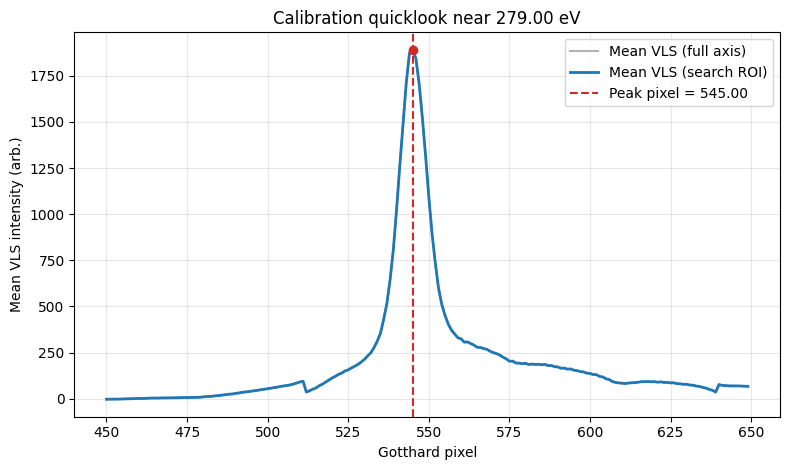

In [44]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(pixel_axis, mean_vls, lw=1.5, color='0.7', label='Mean VLS (full axis)')
ax.plot(roi_pixels, roi_mean_vls, lw=2.0, color='tab:blue', label='Mean VLS (search ROI)')
ax.axvline(peak_pixel, color='tab:red', ls='--', lw=1.5, label=f'Peak pixel = {peak_pixel:.2f}')
ax.plot([peak_pixel], [peak_value], 'o', color='tab:red', ms=6)
ax.set_xlabel('Gotthard pixel')
ax.set_ylabel('Mean VLS intensity (arb.)')
ax.set_title(f'Calibration quicklook near {selected_energy_eV:.2f} eV')
if CALIBRATION_PIXEL_ROI is not None:
    ax.set_xlim(float(CALIBRATION_PIXEL_ROI[0]), float(CALIBRATION_PIXEL_ROI[1]))
ax.grid(alpha=0.3)
ax.legend(loc='best')
fig.tight_layout()
plt.show()

## Helpers

The helper functions below keep the nominal-energy and shot-resolved proxy binning aligned with the existing static-XAS notebooks.

In [45]:
def bin_nominal_energy_run(data, gmd_edges):
    vls = data['vls']
    gmd = data['gmd']
    n_shots = data['n_shots']
    nominal_energies = data['nominal_energies']

    n_energy, _, n_pixels = vls.shape
    n_gmd = len(gmd_edges) - 1

    a_sum = np.zeros((n_energy, n_gmd, n_pixels), dtype=np.float64)
    g_sum = np.zeros((n_energy, n_gmd), dtype=np.float64)
    n_per_bin = np.zeros((n_energy, n_gmd), dtype=np.int64)

    for ie in range(n_energy):
        n = int(n_shots[ie])
        g = gmd[ie, :n]
        a = vls[ie, :n, :]

        finite = np.isfinite(g) & np.all(np.isfinite(a), axis=1)
        if not np.any(finite):
            continue

        g = g[finite]
        a = a[finite]
        bins = np.digitize(g, gmd_edges) - 1
        in_range = (bins >= 0) & (bins < n_gmd)
        if not np.any(in_range):
            continue

        g = g[in_range]
        a = a[in_range]
        bins = bins[in_range]

        np.add.at(n_per_bin[ie], bins, 1)
        np.add.at(g_sum[ie], bins, g)
        np.add.at(a_sum[ie], bins, a)

    safe_n = np.where(n_per_bin > 0, n_per_bin, 1).astype(np.float64)
    g_mean = np.where(n_per_bin > 0, g_sum / safe_n, np.nan)
    a_mean = np.where(n_per_bin[:, :, None] > 0, a_sum / safe_n[:, :, None], np.nan)
    vls_sum = np.nansum(a_mean, axis=2)

    with np.errstate(divide='ignore', invalid='ignore'):
        xas = g_mean / vls_sum

    return {
        'x': nominal_energies,
        'xas': xas,
        'n_per_bin': n_per_bin,
    }


def _gaussian_with_offset(x, offset, amp, center, sigma):
    return offset + amp * np.exp(-0.5 * ((x - center) / sigma) ** 2)


def _center_com(a_valid):
    a_pos = np.maximum(a_valid, 0.0)
    pix = np.arange(a_valid.shape[1], dtype=np.float64)
    a_sum_per_shot = a_pos.sum(axis=1)
    center = np.full(a_valid.shape[0], np.nan, dtype=np.float64)
    nonzero = a_sum_per_shot > 0
    center[nonzero] = (a_pos[nonzero] @ pix) / a_sum_per_shot[nonzero]
    return center


def _center_peak(a_valid):
    a_pos = np.maximum(np.nan_to_num(a_valid, nan=0.0), 0.0)
    peak_val = np.nanmax(a_pos, axis=1)
    center = np.argmax(a_pos, axis=1).astype(np.float64)
    center[peak_val <= 0] = np.nan
    return center


def _center_gaussian(a_valid, half_window=12, chunk_size=50000):
    """
    Fast Gaussian peak-center estimate for many shots.

    For each shot, find the max pixel, take a local window around it,
    subtract a local baseline, and fit log(intensity) with a quadratic.
    A Gaussian becomes quadratic in log space, so the fitted peak is
    -b / (2a). Failed/edge cases fall back to COM.
    """
    n_shots, n_pixels = a_valid.shape
    centers = np.full(n_shots, np.nan, dtype=np.float64)
    fallback = _center_com(a_valid)

    half_window = int(half_window)
    chunk_size = int(chunk_size)
    offsets = np.arange(-half_window, half_window + 1, dtype=np.int64)
    x = offsets.astype(np.float64)
    X = np.column_stack([x ** 2, x, np.ones_like(x)])
    pinv = np.linalg.pinv(X)  # (3, window)
    eps = np.finfo(np.float64).tiny

    for start in range(0, n_shots, chunk_size):
        stop = min(n_shots, start + chunk_size)
        y = np.nan_to_num(a_valid[start:stop], nan=0.0)
        y_pos = np.maximum(y, 0.0)

        peak = np.argmax(y_pos, axis=1)
        peak_val = y_pos[np.arange(y_pos.shape[0]), peak]
        edge_ok = (
            (peak_val > 0)
            & (peak - half_window >= 0)
            & (peak + half_window < n_pixels)
        )
        rows = np.where(edge_ok)[0]
        if rows.size == 0:
            continue

        idx = peak[rows, None] + offsets[None, :]
        yw = y_pos[rows[:, None], idx]
        baseline = np.percentile(yw, 10, axis=1)
        signal = np.maximum(yw - baseline[:, None], eps)
        log_signal = np.log(signal)

        coeff = log_signal @ pinv.T
        a = coeff[:, 0]
        b = coeff[:, 1]
        with np.errstate(divide='ignore', invalid='ignore'):
            center_offset = -b / (2.0 * a)

        valid = (
            np.isfinite(center_offset)
            & (a < 0)
            & (np.abs(center_offset) <= half_window)
        )
        centers[start + rows[valid]] = peak[rows[valid]] + center_offset[valid]

    missing = ~np.isfinite(centers)
    centers[missing] = fallback[missing]
    return centers

def prepare_proxy_shots(
    data,
    vls_intensity_threshold=None,
    center_method='com',
    gaussian_fit_half_window=12,
    gaussian_fit_chunk_size=50000,
):
    vls = data['vls']
    gmd = data['gmd']
    nominal_energies = data['nominal_energies']
    n_pixels = vls.shape[-1]

    gmd_flat = gmd.reshape(-1)
    vls_flat = vls.reshape(-1, n_pixels)
    nominal_energy_flat = np.repeat(nominal_energies, vls.shape[1])

    ok = np.isfinite(gmd_flat) & np.all(np.isfinite(vls_flat), axis=1)
    g_valid = gmd_flat[ok]
    a_valid = vls_flat[ok]
    nominal_energy_valid = nominal_energy_flat[ok]

    peak_vls = np.nanmax(a_valid, axis=1)
    if vls_intensity_threshold is not None:
        keep_peak = peak_vls >= vls_intensity_threshold
        g_valid = g_valid[keep_peak]
        a_valid = a_valid[keep_peak]
        nominal_energy_valid = nominal_energy_valid[keep_peak]

    center_method = str(center_method).lower()
    if center_method == 'com':
        center_float = _center_com(a_valid)
    elif center_method in ('peak', 'max', 'argmax'):
        center_float = _center_peak(a_valid)
        center_method = 'peak'
    elif center_method in ('gaussian', 'gauss', 'fit'):
        center_float = _center_gaussian(
            a_valid,
            half_window=gaussian_fit_half_window,
            chunk_size=gaussian_fit_chunk_size,
        )
        center_method = 'gaussian'
    else:
        raise ValueError("center_method must be 'com', 'peak', or 'gaussian'.")

    valid_center = np.isfinite(center_float)
    g_valid = g_valid[valid_center]
    a_valid = a_valid[valid_center]
    nominal_energy_valid = nominal_energy_valid[valid_center]
    proxy_pixel = np.clip(
        np.round(center_float[valid_center]).astype(np.int64),
        0,
        n_pixels - 1,
    )

    return {
        'g_valid': g_valid,
        'a_valid': a_valid,
        'nominal_energy_valid': nominal_energy_valid,
        'proxy_pixel': proxy_pixel,
        'center_float': center_float[valid_center],
        'center_method': center_method,
    }


def bin_proxy_energy(prepared, vls_pixels, gmd_edges):
    n_gmd = len(gmd_edges) - 1

    a_valid = prepared['a_valid']
    g_valid = prepared['g_valid']
    proxy_pixel = prepared['proxy_pixel']
    n_pixels = a_valid.shape[1]

    proxy_energies = np.sort(np.unique(proxy_pixel))
    pixel_to_idx = {int(p): i for i, p in enumerate(proxy_energies)}
    proxy_idx = np.array([pixel_to_idx[int(p)] for p in proxy_pixel], dtype=np.int64)
    n_proxy_e = len(proxy_energies)

    a_sum = np.zeros((n_proxy_e, n_gmd, n_pixels), dtype=np.float64)
    g_sum = np.zeros((n_proxy_e, n_gmd), dtype=np.float64)
    n_per_bin = np.zeros((n_proxy_e, n_gmd), dtype=np.int64)

    gmd_bins = np.digitize(g_valid, gmd_edges) - 1
    in_range = (gmd_bins >= 0) & (gmd_bins < n_gmd)

    pe = proxy_idx[in_range]
    gb = gmd_bins[in_range]
    g_ir = g_valid[in_range]
    a_ir = a_valid[in_range]

    np.add.at(n_per_bin, (pe, gb), 1)
    np.add.at(g_sum, (pe, gb), g_ir)
    np.add.at(a_sum, (pe, gb), a_ir)

    safe_n = np.where(n_per_bin > 0, n_per_bin, 1).astype(np.float64)
    g_mean = np.where(n_per_bin > 0, g_sum / safe_n, np.nan)
    a_mean = np.where(n_per_bin[:, :, None] > 0, a_sum / safe_n[:, :, None], np.nan)
    vls_sum = np.nansum(a_mean, axis=2)

    with np.errstate(divide='ignore', invalid='ignore'):
        xas = g_mean / vls_sum

    proxy_pixels_abs = vls_pixels[proxy_energies].astype(np.float64)

    return {
        'x': proxy_pixels_abs,
        'x_rel': proxy_energies,
        'xas': xas,
        'n_per_bin': n_per_bin,
    }


def build_pixel_map_config(config_dict, calibration_dict):
    cfg = SpectrometerConfig(**config_dict)
    cal = CalibrationPoint(**calibration_dict)
    return cfg, cal


def convert_proxy_pixels_to_energy(proxy_pixels_abs, config_dict, calibration_dict, e_range, n_samples):
    cfg, cal = build_pixel_map_config(config_dict, calibration_dict)
    energies = pixel_to_energy(
        proxy_pixels_abs,
        cfg,
        cal,
        e_min=float(e_range[0]),
        e_max=float(e_range[1]),
        n_samples=int(n_samples),
    )
    return energies, cfg, cal


def plot_xas_curves(x, xas, gmd_edges, x_label, title, ylim=None, figsize=(8.0, 4.8), linewidth=1.8):
    n_gmd = len(gmd_edges) - 1
    cmap = plt.get_cmap('viridis')

    fig, ax = plt.subplots(figsize=figsize)
    for g in range(n_gmd):
        color = cmap(g / max(n_gmd - 1, 1))
        ax.plot(
            x,
            xas[:, g],
            lw=linewidth,
            color=color,
            label=f'[{gmd_edges[g]:.2f}, {gmd_edges[g + 1]:.2f}) uJ',
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel('XAS = <GMD> / sum_pix(<VLS>)')
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)
    ax.legend(title='GMD bin', fontsize=8, title_fontsize=9, loc='best')
    fig.tight_layout()
    plt.show()

## Process Run 58794

This cell reuses the already loaded static-XAS data, builds the nominal-energy result, the shot-resolved pixel proxy result, and the converted photon-energy axis from the proxy pixels.

In [46]:
nominal = bin_nominal_energy_run(data, GMD_EDGES)
proxy_prepared = prepare_proxy_shots(
    data,
    vls_intensity_threshold=VLS_INTENSITY_THRESHOLD,
    center_method=CENTER_METHOD,
    gaussian_fit_half_window=GAUSSIAN_FIT_HALF_WINDOW,
    gaussian_fit_chunk_size=GAUSSIAN_FIT_CHUNK_SIZE,
)
proxy = bin_proxy_energy(proxy_prepared, data['vls_pixels'], GMD_EDGES)
proxy_energy_eV, pixel_map_cfg, pixel_map_cal = convert_proxy_pixels_to_energy(
    proxy['x'],
    PIXEL_MAP_CONFIG,
    PIXEL_MAP_CALIBRATION,
    INVERSE_MAP_RANGE_EV,
    INVERSE_MAP_SAMPLES,
)
converted = {
    'x': proxy_energy_eV,
    'xas': proxy['xas'],
    'n_per_bin': proxy['n_per_bin'],
}

print(f'run                    : {data["attrs"].get("run_no")}')
print(f'input shape            : {data["vls"].shape}')
print(f'nominal energy range   : {data["nominal_energies"][0]:.2f} .. {data["nominal_energies"][-1]:.2f} eV')
print(f'total stored shots     : {int(data["n_shots"].sum())}')
print(f'proxy-valid shots      : {len(proxy_prepared["g_valid"])}')
print(f'center method          : {proxy_prepared["center_method"]}')
print(f'proxy pixel range      : {proxy["x"][0]:.1f} .. {proxy["x"][-1]:.1f}')
print(f'converted energy range : {np.nanmin(converted["x"]):.3f} .. {np.nanmax(converted["x"]):.3f} eV')
print(f'vls crop roi           : {data["attrs"].get("vls_crop_roi")}')
print(f'signal bunch range     : {data["attrs"].get("signal_bunch_range")}')
print(f'pixel-map magnification: {pixel_map_cfg.magnification}')
print(f'calibration anchor     : pixel {pixel_map_cal.pixel:.1f} -> {pixel_map_cal.energy_eV:.3f} eV')

run                    : 58794
input shape            : (31, 102720, 200)
nominal energy range   : 286.00 .. 271.00 eV
total stored shots     : 1164240
proxy-valid shots      : 397350
center method          : peak
proxy pixel range      : 516.0 .. 589.0
converted energy range : 270.845 .. 284.593 eV
vls crop roi           : [450 650]
signal bunch range     : [10 40]
pixel-map magnification: 3.0
calibration anchor     : pixel 545.0 -> 279.000 eV


## Mean VLS at one nominal energy, per GMD bin

Choose one nominal photon energy, split its shots by `GMD_EDGES`, then plot the mean processed VLS spectrum in each GMD bin. This uses the stored processed `vls` and `gmd` arrays directly; no COM or proxy-energy calculation is used.


selected energy index : 14
selected nominal E    : 279.000 eV
finite shots at E     : 11360 / 17040
shots per GMD bin   : [1413 3331 4746 1854]
CoM pixel per bin   : [556.42 556.59 556.63 556.73]


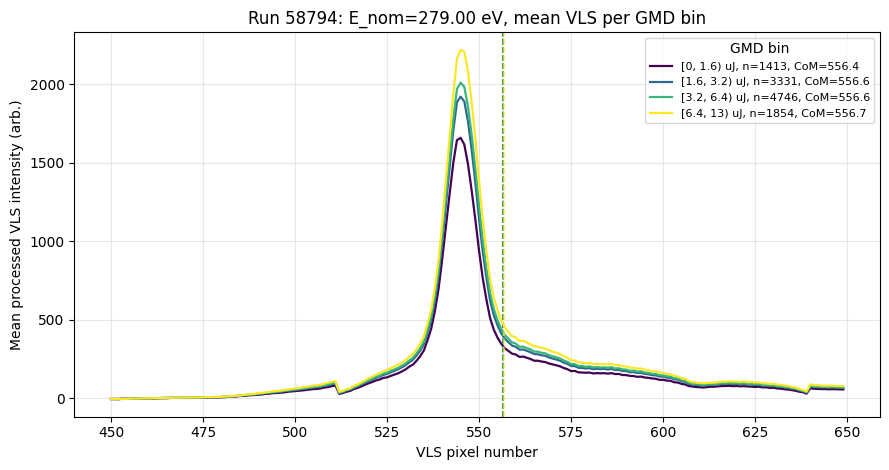

In [47]:
# Choose the nominal energy section to inspect.
# If SELECT_NOMINAL_ENERGY_EV is not None, the nearest stored nominal energy is used.
SELECT_NOMINAL_ENERGY_EV = 279.0
SELECT_ENERGY_INDEX = 0

vls = data['vls']
gmd = data['gmd']
n_shots = data['n_shots']
energies = data['nominal_energies']
vls_pixels = data['vls_pixels']

if SELECT_NOMINAL_ENERGY_EV is not None:
    ie = int(np.argmin(np.abs(energies - float(SELECT_NOMINAL_ENERGY_EV))))
else:
    ie = int(SELECT_ENERGY_INDEX)

if not (0 <= ie < len(energies)):
    raise IndexError(f"energy index {ie} out of range [0, {len(energies) - 1}]")

n = int(n_shots[ie])
A = vls[ie, :n, :]
G = gmd[ie, :n]

ok = np.isfinite(G) & np.all(np.isfinite(A), axis=1)
A = A[ok]
G = G[ok]

n_gmd = len(GMD_EDGES) - 1
mean_vls = np.full((n_gmd, A.shape[1]), np.nan, dtype=np.float64)
com_pixel = np.full(n_gmd, np.nan, dtype=np.float64)
n_by_gmd = np.zeros(n_gmd, dtype=np.int64)
bins = np.digitize(G, GMD_EDGES) - 1

for ib in range(n_gmd):
    keep = bins == ib
    n_by_gmd[ib] = int(np.sum(keep))
    if n_by_gmd[ib] > 0:
        mean_vls[ib] = np.nanmean(A[keep], axis=0)
        weights = np.nan_to_num(mean_vls[ib], nan=0.0)
        weights = np.maximum(weights, 0.0)
        if weights.sum() > 0:
            com_pixel[ib] = np.sum(vls_pixels * weights) / np.sum(weights)

print(f"selected energy index : {ie}")
print(f"selected nominal E    : {energies[ie]:.3f} eV")
print(f"finite shots at E     : {len(G)} / {n}")
print("shots per GMD bin   :", n_by_gmd)
print("CoM pixel per bin   :", np.round(com_pixel, 2))

fig, ax = plt.subplots(figsize=(9, 4.8))
cmap = plt.get_cmap('viridis')
for ib in range(n_gmd):
    if n_by_gmd[ib] == 0:
        continue
    color = cmap(ib / max(n_gmd - 1, 1))
    label = f'[{GMD_EDGES[ib]:.2g}, {GMD_EDGES[ib + 1]:.2g}) uJ, n={n_by_gmd[ib]}, CoM={com_pixel[ib]:.1f}'
    ax.plot(vls_pixels, mean_vls[ib], lw=1.6, color=color, label=label)
    if np.isfinite(com_pixel[ib]):
        ax.axvline(com_pixel[ib], color=color, ls='--', lw=1.1, alpha=0.85)

ax.set_xlabel('VLS pixel number')
ax.set_ylabel('Mean processed VLS intensity (arb.)')
ax.set_title(f'Run {RUN_NO}: E_nom={energies[ie]:.2f} eV, mean VLS per GMD bin')
ax.grid(alpha=0.3)
ax.legend(title='GMD bin', fontsize=8)
fig.tight_layout()
plt.show()


## Random 10 shot VLS spectra and CoM

Randomly sample 10 finite shots from the selected nominal-energy section and mark each shot CoM with a dashed line.


selected nominal E : 279.000 eV
random shots       : 10 / 11360 finite shots
shot indices       : [9655 9238 7230 5802 3063  465  187 3495 1990  854]
shot GMD (uJ)      : [1.892 3.175 5.063 5.272 2.368 7.167 3.422 0.44  7.084 1.921]
shot CoM pixels   : [554.71 555.79 555.6  553.89 557.99 553.67 555.05 555.86 557.55 553.43]


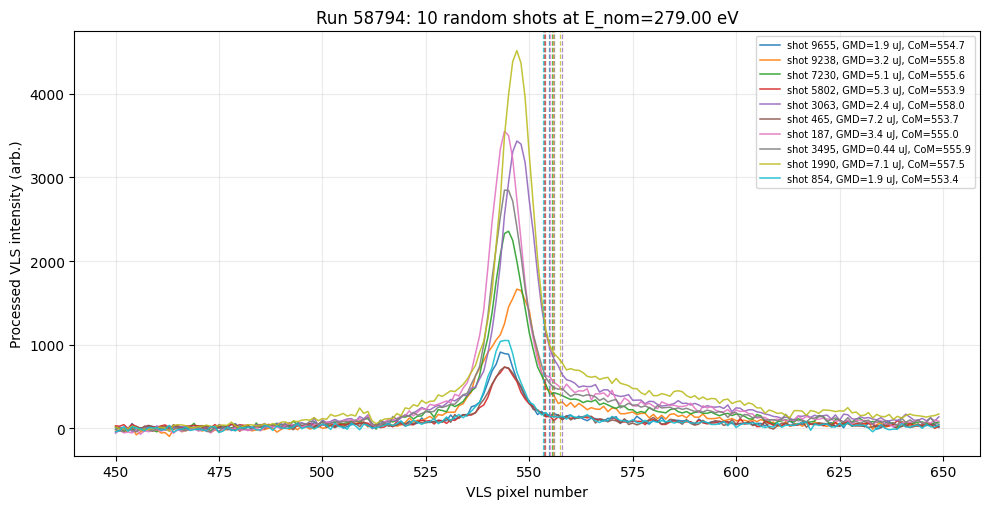

In [48]:
N_RANDOM_SHOTS = 10
RANDOM_SEED = 0

# Reuse the selected nominal-energy section from the previous cell.
# If that cell has not been run, this recomputes A/G for the selected energy.
vls = data['vls']
gmd = data['gmd']
n_shots = data['n_shots']
energies = data['nominal_energies']
vls_pixels = data['vls_pixels']

if SELECT_NOMINAL_ENERGY_EV is not None:
    ie = int(np.argmin(np.abs(energies - float(SELECT_NOMINAL_ENERGY_EV))))
else:
    ie = int(SELECT_ENERGY_INDEX)

n = int(n_shots[ie])
A_all = vls[ie, :n, :]
G_all = gmd[ie, :n]
ok = np.isfinite(G_all) & np.all(np.isfinite(A_all), axis=1)
A_valid = A_all[ok]
G_valid = G_all[ok]

rng = np.random.default_rng(RANDOM_SEED)
n_pick = min(N_RANDOM_SHOTS, A_valid.shape[0])
pick = rng.choice(A_valid.shape[0], size=n_pick, replace=False)

shot_com = np.full(n_pick, np.nan, dtype=np.float64)
for j, idx in enumerate(pick):
    weights = np.nan_to_num(A_valid[idx], nan=0.0)
    weights = np.maximum(weights, 0.0)
    if weights.sum() > 0:
        shot_com[j] = np.sum(vls_pixels * weights) / np.sum(weights)

print(f"selected nominal E : {energies[ie]:.3f} eV")
print(f"random shots       : {n_pick} / {A_valid.shape[0]} finite shots")
print("shot indices       :", pick)
print("shot GMD (uJ)      :", np.round(G_valid[pick], 3))
print("shot CoM pixels   :", np.round(shot_com, 2))

fig, ax = plt.subplots(figsize=(10, 5.2))
cmap = plt.get_cmap('tab10')
for j, idx in enumerate(pick):
    color = cmap(j % 10)
    label = f"shot {idx}, GMD={G_valid[idx]:.2g} uJ, CoM={shot_com[j]:.1f}"
    ax.plot(vls_pixels, A_valid[idx], lw=1.1, color=color, alpha=0.9, label=label)
    if np.isfinite(shot_com[j]):
        ax.axvline(shot_com[j], color=color, ls='--', lw=0.9, alpha=0.75)

ax.set_xlabel('VLS pixel number')
ax.set_ylabel('Processed VLS intensity (arb.)')
ax.set_title(f'Run {RUN_NO}: 10 random shots at E_nom={energies[ie]:.2f} eV')
ax.grid(alpha=0.25)
ax.legend(fontsize=7, ncol=1, loc='best')
fig.tight_layout()
plt.show()


## XAS vs nominal photon energy

This reproduces the standard static-XAS view using the nominal scan energy as the x axis.

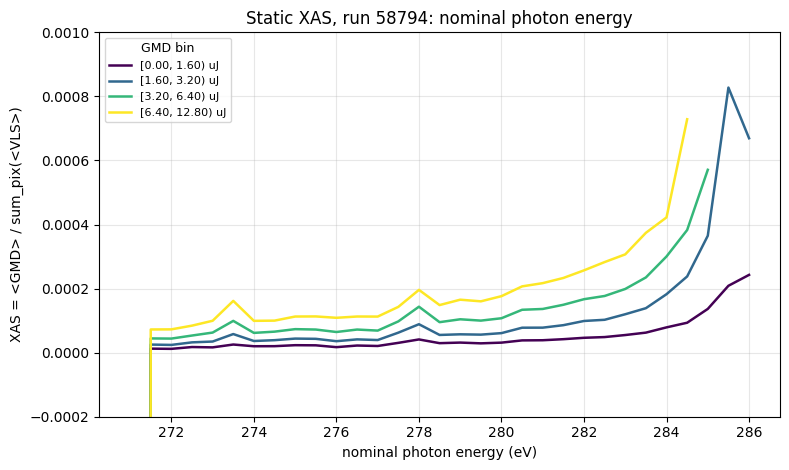

In [49]:
plot_xas_curves(
    x=nominal['x'],
    xas=nominal['xas'],
    gmd_edges=GMD_EDGES,
    x_label='nominal photon energy (eV)',
    title=f'Static XAS, run {RUN_NO}: nominal photon energy',
    ylim=YLIM,
    figsize=FIGSIZE,
    linewidth=LINEWIDTH,
)

## XAS vs shot-resolved pixel proxy

The x axis here is the rounded VLS centre-of-mass expressed as absolute Gotthard pixel index.

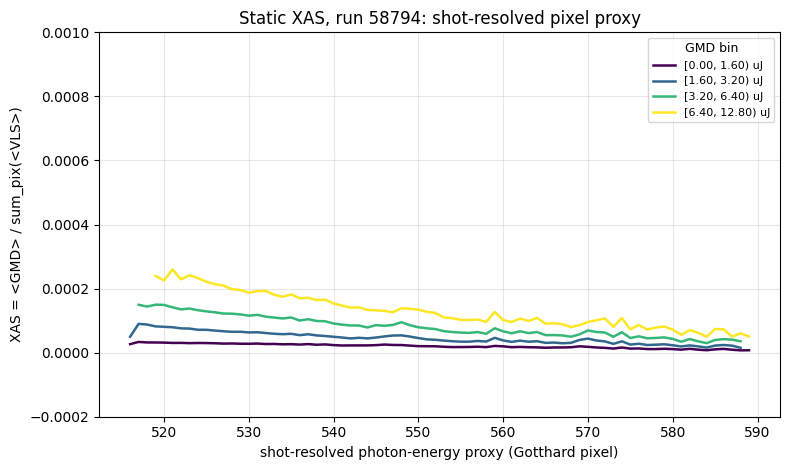

In [50]:
plot_xas_curves(
    x=proxy['x'],
    xas=proxy['xas'],
    gmd_edges=GMD_EDGES,
    x_label='shot-resolved photon-energy proxy (Gotthard pixel)',
    title=f'Static XAS, run {RUN_NO}: shot-resolved pixel proxy',
    ylim=YLIM,
    figsize=FIGSIZE,
    linewidth=LINEWIDTH,
)

## XAS vs converted photon energy

This uses the same shot-resolved proxy binning as the previous cell, but converts the proxy pixel axis to photon energy with the configurable Gotthard pixel map.

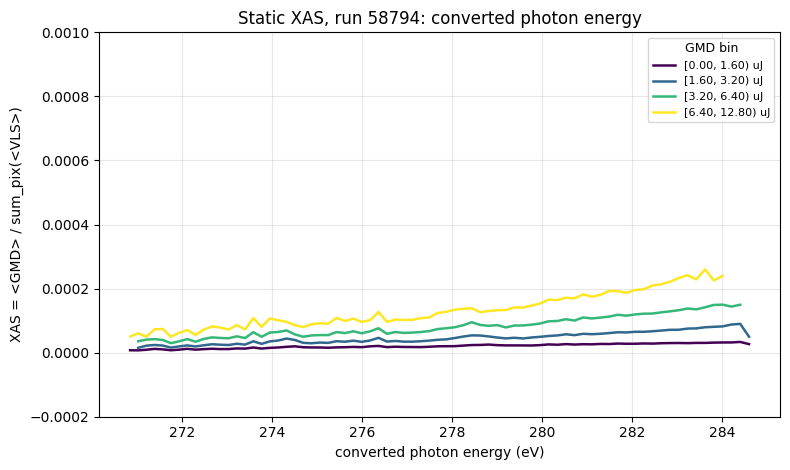

In [51]:
plot_xas_curves(
    x=converted['x'],
    xas=converted['xas'],
    gmd_edges=GMD_EDGES,
    x_label='converted photon energy (eV)',
    title=f'Static XAS, run {RUN_NO}: converted photon energy',
    ylim=YLIM,
    figsize=FIGSIZE,
    linewidth=LINEWIDTH,
)